In [1]:
import pandas as pd
import numpy as np
import scipy as stats

df = pd.read_csv('../data/processed/ipo_master_returns.csv')
print(df.shape)
df.info()

(397, 39)
<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nse_symbol           397 non-null    str    
 1   company_name         397 non-null    str    
 2   listing_date         397 non-null    str    
 3   issue_price          397 non-null    int64  
 4   listing_price        397 non-null    float64
 5   pop_pct              397 non-null    float64
 6   close_6mo            397 non-null    float64
 7   close_1yr            319 non-null    float64
 8   close_2yr            238 non-null    float64
 9   close_3yr            163 non-null    float64
 10  return_6mo           397 non-null    float64
 11  return_1yr           319 non-null    float64
 12  return_2yr           238 non-null    float64
 13  return_3yr           163 non-null    float64
 14  cagr_6mo             397 non-null    float64
 15  cagr_1yr             319 non-null    floa

In [2]:
#companies per listing year
df['listing_date'] = pd.to_datetime(df['listing_date'].astype(str).str[:10])
df['listing_year'] = df['listing_date'].dt.year

print(df.groupby('listing_year').size())

listing_year
2018     22
2019     16
2020     15
2021     63
2022     38
2023     57
2024     81
2025    105
dtype: int64


In [3]:
horizon_cols = ['relative_cagr_6mo','relative_cagr_1yr','relative_cagr_2yr','relative_cagr_3yr']
print(df[horizon_cols].isnull().sum())

relative_cagr_6mo      0
relative_cagr_1yr     78
relative_cagr_2yr    159
relative_cagr_3yr    234
dtype: int64


In [4]:
#null patern by listing year
df.groupby('listing_year')[horizon_cols].apply(lambda x:x.isnull().sum())

,relative_cagr_6mo,relative_cagr_1yr,relative_cagr_2yr,relative_cagr_3yr
listing_year,,,,
2018,0,0,0,0
2019,0,0,0,0
2020,0,0,0,0
2021,0,0,0,0
2022,0,0,0,0
2023,0,0,0,48
2024,0,0,54,81
2025,0,78,105,105


In [5]:
horizon_cutoff_year = {
    'relative_cagr_6mo' :2025,
    'relative_cagr_1yr':2024,
    'relative_cagr_2yr':2023,
    'relative_cagr_3yr':2022,
}

def mature_subset (df, horizon_col):
    """Return only rows from listing years fully matured for the horizon"""
    max_year = horizon_cutoff_year[horizon_col]
    return df[df['listing_year'] <= max_year]

In [6]:
summary_rows = []

for horizon in horizon_cutoff_year:    
    sub = mature_subset(df, horizon)
    grouped = sub.groupby('listing_year')[horizon].agg(['median','mean','count'])
    grouped['horizon'] = horizon
    summary_rows.append(grouped)
cohort_summary = pd.concat(summary_rows).reset_index()
cohort_summary = cohort_summary.pivot(index ='listing_year', columns = 'horizon', values = 'median')

In [7]:
cohort_summary = cohort_summary[horizon_cols]
cohort_summary

horizon,relative_cagr_6mo,relative_cagr_1yr,relative_cagr_2yr,relative_cagr_3yr
listing_year,,,,
2018,-59.192387,-40.434550,-25.550390,-26.403303
2019,-42.526475,-23.976608,-13.131365,-11.288832
2020,8.957883,-9.330852,-12.947679,-10.965779
2021,-36.459008,-33.788840,-19.855443,-13.305692
2022,13.685909,9.117297,-0.740461,-10.126664
2023,-9.129747,-6.105273,-13.840426,NaN
2024,-20.150235,-14.817643,NaN,NaN
2025,-21.804799,NaN,NaN,NaN


In [8]:
def bootstrap_median_ci(values,n_boot =5000,ci =95,random_state =42):
    values = values.dropna().values
    rng = np.random.default_rng(random_state) #random number generator
    boot_medians = np.empty(n_boot) #empty array

    for i in range(n_boot):
        sample = rng.choice(values, size = len(values), replace =True)
        boot_medians[i] = np.median(sample)

    lower = (100-ci)/2
    upper = 100-lower
    ci_low,ci_high = np.percentile(boot_medians,[lower,upper])

    return pd.Series({'median': np.median(values),
    'ci_low':ci_low,
    'ci_high':ci_high,
    'n':len(values)
                     })

In [9]:
bootstrap_rows = []

for horizon in horizon_cols:
    sub = mature_subset(df, horizon)
    result = sub.groupby('listing_year')[horizon].apply(bootstrap_median_ci)
    result = result.unstack()
    result['horizon'] = horizon
    bootstrap_rows.append(result.reset_index())

bootstrap_summary = pd.concat(bootstrap_rows, ignore_index = True)
bootstrap_summary = bootstrap_summary[["listing_year", "horizon", "n", "median", "ci_low", "ci_high"]]
bootstrap_summary

,listing_year,horizon,n,median,ci_low,ci_high
0,2018,relative_cagr_6mo,22.0,-59.192387,-83.602198,-37.934410
1,2019,relative_cagr_6mo,16.0,-42.526475,-54.324962,14.925249
2,2020,relative_cagr_6mo,15.0,8.957883,-125.172111,59.652326
3,2021,relative_cagr_6mo,63.0,-36.459008,-50.032700,-23.322644
4,2022,relative_cagr_6mo,38.0,13.685909,-27.930996,42.749848
5,2023,relative_cagr_6mo,57.0,-9.129747,-25.535079,22.722193
6,2024,relative_cagr_6mo,81.0,-20.150235,-35.724065,-0.522589
7,2025,relative_cagr_6mo,105.0,-21.804799,-29.261754,-11.579055
8,2018,relative_cagr_1yr,22.0,-40.434550,-58.595351,-14.015400
9,2019,relative_cagr_1yr,16.0,-23.976608,-53.138462,3.700471


In [10]:
from scipy.stats import mannwhitneyu, wilcoxon

# Test A: 2021 vs all other years combined, per horizon
test_a_rows = []

for horizon in horizon_cols:
    sub = mature_subset(df, horizon)
    group_2021 = sub.loc[sub["listing_year"] == 2021, horizon].dropna()
    group_rest = sub.loc[sub["listing_year"] != 2021, horizon].dropna()
    
    stat, p_value = mannwhitneyu(group_2021, group_rest, alternative="two-sided")
    
    test_a_rows.append({
        "horizon": horizon,
        "n_2021": len(group_2021),
        "n_rest": len(group_rest),
        "median_2021": group_2021.median(),
        "median_rest": group_rest.median(),
        "u_stat": stat,
        "p_value": p_value
    })

test_a_results = pd.DataFrame(test_a_rows)
test_a_results

,horizon,n_2021,n_rest,median_2021,median_rest,u_stat,p_value
0,relative_cagr_6mo,63,334,-36.459008,-19.955476,8416.0,0.011764
1,relative_cagr_1yr,63,229,-33.788840,-10.019300,5257.0,0.000982
2,relative_cagr_2yr,63,148,-19.855443,-11.434620,3849.0,0.045294
3,relative_cagr_3yr,63,91,-13.305692,-12.177741,2700.0,0.541851


In [11]:
# Test B: is each cohort's relative CAGR significantly different from zero?
test_b_rows = []

for horizon in horizon_cols:
    sub = mature_subset(df, horizon)
    for year, group in sub.groupby("listing_year")[horizon]:
        values = group.dropna()
        if len(values) < 5:  # too few data points for a meaningful test
            continue
        stat, p_value = wilcoxon(values)
        test_b_rows.append({
            "listing_year": year,
            "horizon": horizon,
            "n": len(values),
            "median": values.median(),
            "p_value": p_value
        })

test_b_results = pd.DataFrame(test_b_rows)
test_b_results

,listing_year,horizon,n,median,p_value
0,2018,relative_cagr_6mo,22,-59.192387,0.005929
1,2019,relative_cagr_6mo,16,-42.526475,0.073914
2,2020,relative_cagr_6mo,15,8.957883,1.000000
3,2021,relative_cagr_6mo,63,-36.459008,0.001262
4,2022,relative_cagr_6mo,38,13.685909,0.220433
5,2023,relative_cagr_6mo,57,-9.129747,0.532825
6,2024,relative_cagr_6mo,81,-20.150235,0.109940
7,2025,relative_cagr_6mo,105,-21.804799,0.272159
8,2018,relative_cagr_1yr,22,-40.434550,0.025139
9,2019,relative_cagr_1yr,16,-23.976608,0.192810


In [12]:
#companies that outperformed nifty
winners_rows =[]

for horizon in horizon_cols:
    sub = mature_subset(df, horizon)
    grouped = sub.groupby("listing_year")[horizon].apply(lambda x:(x.dropna()>0).mean() * 100)
    grouped = grouped.rename("pct_beating_nifty").reset_index()
    grouped['horizon'] = horizon
    winners_rows.append(grouped)

winners_summary = pd.concat(winners_rows , ignore_index = True)
winners_pivot = winners_summary.pivot(index = 'listing_year',columns = 'horizon' ,values = 'pct_beating_nifty')
winners_pivot = winners_pivot[horizon_cols]
winners_pivot    

horizon,relative_cagr_6mo,relative_cagr_1yr,relative_cagr_2yr,relative_cagr_3yr
listing_year,,,,
2018,27.272727,27.272727,27.272727,31.818182
2019,37.500000,37.500000,43.750000,43.750000
2020,53.333333,46.666667,20.000000,33.333333
2021,23.809524,22.222222,25.396825,38.095238
2022,52.631579,60.526316,44.736842,39.473684
2023,47.368421,45.614035,36.842105,NaN
2024,38.271605,30.864198,NaN,NaN
2025,37.142857,NaN,NaN,NaN


In [13]:
#best and worst 10 performers on the basis on 3-years relative cagr
mature_3yr = mature_subset(df, 'relative_cagr_3yr')
cols_to_show = ['company_name', 'listing_year', 'relative_cagr_3yr']

best_10 = mature_3yr.nlargest(10, 'relative_cagr_3yr')[cols_to_show]
worst_10 = mature_3yr.nsmallest(10, 'relative_cagr_3yr')[cols_to_show]

print('Best 10:')
print(best_10)
print('Worst 10:')
print(worst_10)

Best 10:
                                    company_name  listing_year  \
252              Kaynes Technology India Limited          2022   
342   Indian Railway Finance Corporation Limited          2021   
368                         Neogen Chemicals Ltd          2019   
374          Xelpmoc Design and Technologies Ltd          2019   
330               Kalyan Jewellers India Limited          2021   
350                Mazagon Dock Shipbuilders Ltd          2020   
269                  Venus Pipes & Tubes Limited          2022   
369                            Polycab India Ltd          2019   
337         Railtel Corporation of India Limited          2021   
271  Prudent Corporate Advisory Services Limited          2022   

     relative_cagr_3yr  
252          83.905162  
342          70.773496  
368          69.435841  
374          69.423550  
330          60.503738  
350          50.699807  
269          47.492114  
369          45.031955  
337          43.535657  
271          4

In [14]:
df.to_csv('../data/processed/ipo_master_returns.csv')
cohort_summary.to_csv("../data/processed/cohort_summary.csv")
bootstrap_summary.to_csv("../data/processed/bootstrap_summary.csv", index=False)
winners_pivot.to_csv("../data/processed/winners_pivot.csv")

## Step 4 Summary: Cohort Decay Analysis (Part A)

Grouped all 397 IPOs by listing year and compared median `relative_cagr` (IPO CAGR − Nifty CAGR) across four horizons (6mo/1yr/2yr/3yr). To keep comparisons fair, each horizon only includes listing years old enough to have fully matured for it as of the fixed 2026-06-30 cutoff — e.g., 3-year comparisons exclude 2023–2025, since those cohorts haven't all reached that mark yet.

**Findings:**

- **2018 and 2021 are the only cohorts with statistically significant, sustained underperformance against Nifty** — negative at every single horizon (Wilcoxon signed-rank test, p < 0.05 throughout), backed by bootstrapped 95% CIs that stay entirely below zero across all four horizons. Every other cohort (2019, 2020, 2022, 2023, 2024) is inconsistent — significant at one or two horizons but not others, more consistent with noise than a real effect.
  
- **2021 significantly underperforms the rest of the market at 6mo/1yr/2yr** (Mann-Whitney U, p = 0.012, 0.001, 0.045), but that gap closes by 3yr (p = 0.54) — not because 2021 recovers, but because the *rest* of the market's IPOs catch down to a similarly negative level by year three.
- **2021's win-rate against Nifty rises from 24% at 1yr to 38% at 3yr** — a growing minority of 2021 IPOs recover over time, even as the cohort's median return stays deeply negative. The distribution is widening, not shifting.

  
- **6 of the 10 worst 3-year performers in the entire dataset are 2021 listings**, including high-profile names like Nykaa (-65.1% relative CAGR) and Nazara Technologies (-70.6%).


**Limitation:** 2019 and 2020 (n=15–16) have wide bootstrap CIs and inconsistent significance across horizons — treated as inconclusive, not evidence of good or bad performance, given the small sample.


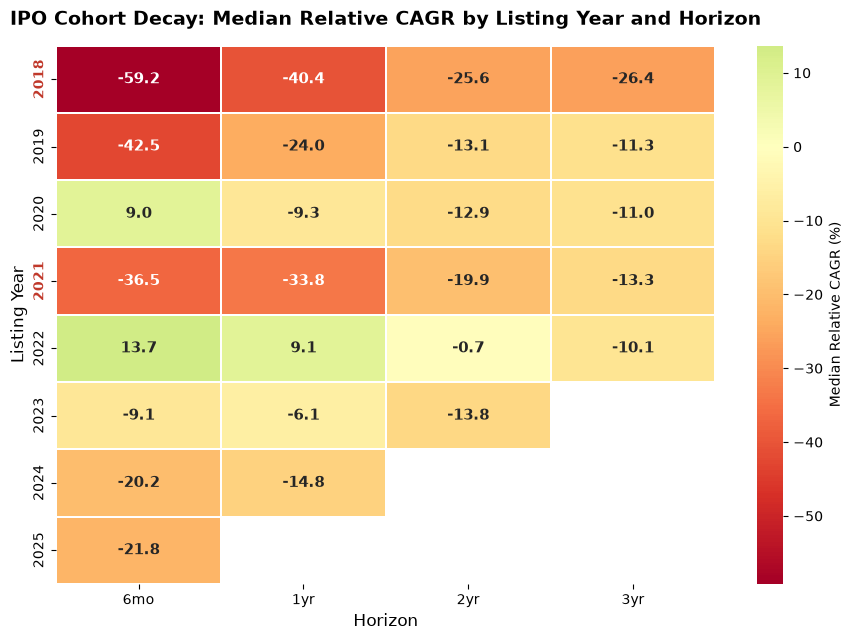

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cohort_summary_display = cohort_summary.copy()
cohort_summary_display.columns = ["6mo", "1yr", "2yr", "3yr"]

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(
    cohort_summary_display,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 11, "fontweight": "bold"},
    cbar_kws={"label": "Median Relative CAGR (%)"},
    ax=ax
)

for label in ax.get_yticklabels():
    if label.get_text() in ("2018", "2021"):
        label.set_fontweight("bold")
        label.set_color("#c0392b")

plt.title("IPO Cohort Decay: Median Relative CAGR by Listing Year and Horizon", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Horizon", fontsize=12)
plt.ylabel("Listing Year", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

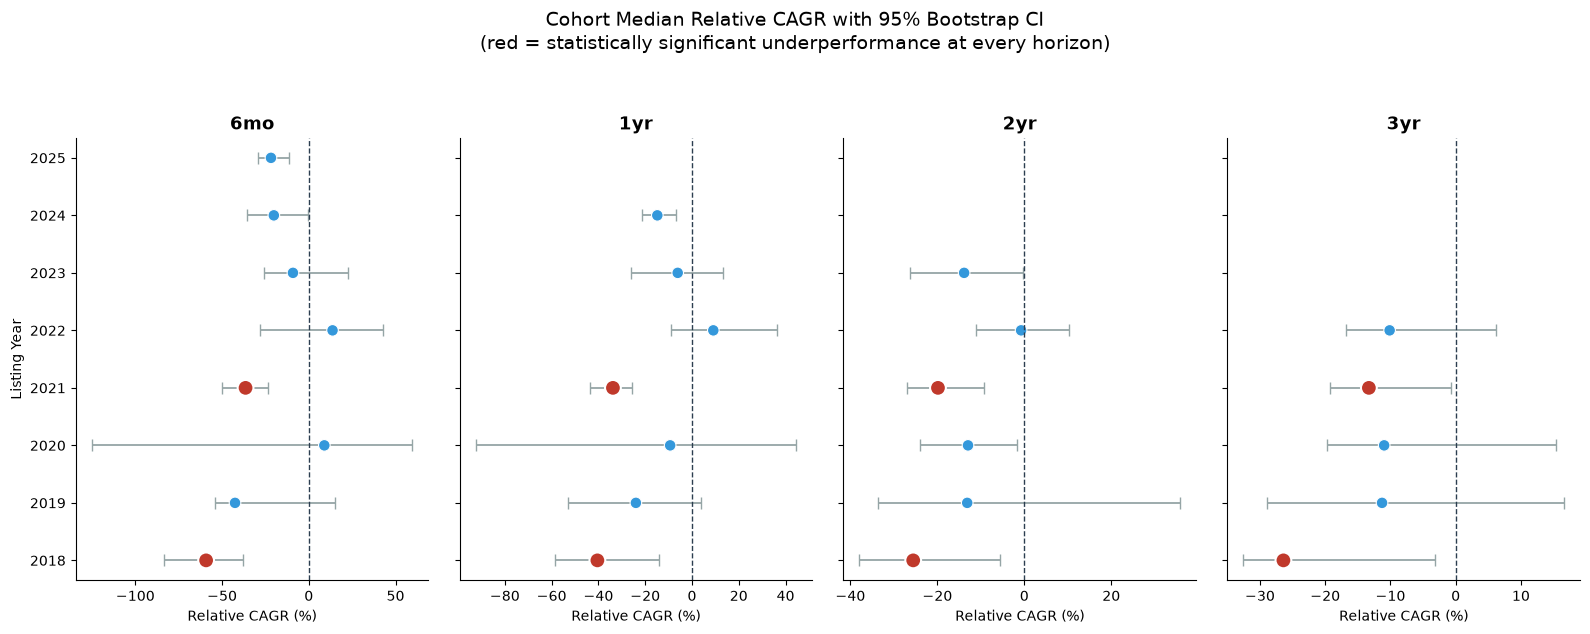

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)

significant_years = {2018, 2021}

for ax, horizon in zip(axes, horizon_cols):
    sub = bootstrap_summary[bootstrap_summary["horizon"] == horizon].sort_values("listing_year")
    
    colors = ["#c0392b" if y in significant_years else "#3498db" for y in sub["listing_year"]]
    sizes = [130 if y in significant_years else 70 for y in sub["listing_year"]]
    edge_widths = [1.5 if y in significant_years else 0.8 for y in sub["listing_year"]]
    
    ax.errorbar(
        sub["median"], sub["listing_year"],
        xerr=[sub["median"] - sub["ci_low"], sub["ci_high"] - sub["median"]],
        fmt="none", ecolor="#95a5a6", capsize=4, zorder=1, linewidth=1.3
    )
    ax.scatter(
        sub["median"], sub["listing_year"],
        color=colors, s=sizes, zorder=2,
        edgecolor="white", linewidth=edge_widths
    )
    ax.axvline(0, color="#2c3e50", linestyle="--", linewidth=1)
    ax.set_title(horizon.replace("relative_cagr_", ""), fontsize=13, fontweight="bold")
    ax.set_xlabel("Relative CAGR (%)")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Listing Year")
fig.suptitle("Cohort Median Relative CAGR with 95% Bootstrap CI\n(red = statistically significant underperformance at every horizon)", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()